In [9]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
camera_hardware = camera_SPC3
camera_logic = camera_logic

In [2]:
camera_hardware._NFrames = 1 
camera_hardware._apply_camera_settings() 

In [ ]:
frames_logic = camera_logic.start_single_acquisition()
camera = camera_logic._camera()
# requested = getattr(cam, "_NFrames", frames.shape[1])

In [5]:
print(f"Acquiring snap with _NFrames={camera_logic._NFrames}...")
try:
    frames = camera_logic.start_single_acquisition()
    if frames is None:
        print("ERROR: start_single_acquisition returned None!")
    else:
        print(f"SUCCESS: Acquired frames with shape {frames.shape}")
except Exception as e:
    print(f"ERROR: {e}")
    import traceback
    traceback.print_exc()


AttributeError: 'CameraLogic' object has no attribute '_NFrames'

========= Remote Traceback (1) =========
Traceback (most recent call last):
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\rpyc\core\protocol.py", line 359, in _dispatch_request
    res = self._HANDLERS[handler](self, *args)
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\rpyc\core\protocol.py", line 853, in _handle_getattr
    return self._access_attr(obj, name, (), "_rpyc_getattr", "allow_getattr", getattr)
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\rpyc\core\protocol.py", line 781, in _access_attr
    return accessor(obj, name, *args)
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\qudi\core\services.py", line 264, in __getattribute__
    attr = getattr(obj, name)
AttributeError: 'CameraLogic' object has no attribute '_NFrames'


In [6]:
print(f"Full frames shape: {frames.shape}")
print(f"Data type: {frames.dtype}")
print(f"Requested frames: {camera._NFrames}")

# Extract only the requested number of frames (discard buffer padding)
num_requested = camera_logic._NFrames
actual_frames = frames[:, :num_requested, :, :]
print(f"Cropped frames shape: {actual_frames.shape}")

# Display first frame
plt.figure(figsize=(8, 6))
plt.imshow(actual_frames[0, 0, :, :], cmap='hot')
plt.colorbar(label='Counts')
plt.title(f'Frame 0 (requested={num_requested}, buffered shape={frames.shape})')
plt.show()


Full frames shape: (1, 2, 32, 32)
Data type: uint8


NameError: name 'camera' is not defined

In [ ]:
# Debug: check frame statistics (counts buffer vs GUI-equivalent cps)
frame_counts = actual_frames[0, 0, :, :]
print(f"Counts frame min: {frame_counts.min()} max: {frame_counts.max()} mean: {frame_counts.mean():.1f} std: {frame_counts.std():.1f}")
print(f"Non-zero pixels (counts): {(frame_counts > 0).sum()}")

# Stats for GUI-equivalent frame (cps) from previous cell
try:
    units = camera_logic.get_display_units()
    exp = camera_logic.get_exposure()
    print(f"GUI units: {units}, exposure: {exp}")
    print(f"CPS frame min: {img.min()} max: {img.max()} mean: {img.mean():.1f} std: {img.std():.1f}")
except NameError:
    print("GUI-equivalent frame 'img' not found; run the previous cell first.")

EOFError: stream has been closed

Loaded shape: (1, 100, 32, 32)


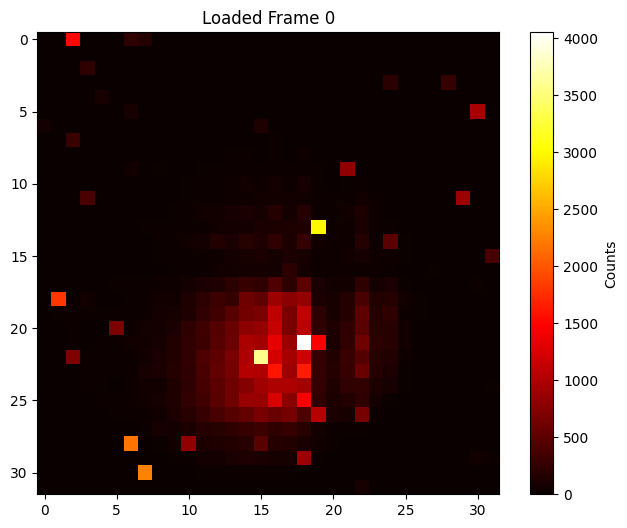

In [10]:
# Load and verify saved data later
success = camera_hardware.load_acquisition_file("C:\\Users\\SPUD1\\Documents\\SPAD\\images\\testing_qudi_img_acq_lizzie\\test2.spc3")
if success:
    loaded_frames = camera_hardware._loaded_frames
    print(f"Loaded shape: {loaded_frames.shape}")
    
    # Display the first frame
    plt.figure(figsize=(8, 6))
    plt.imshow(loaded_frames[0, 0, :, :], cmap='hot')
    plt.colorbar(label='Counts')
    plt.title('Loaded Frame 0')
    plt.show()


In [ ]:
# Check if live mode is active (common issue)
print(f"Live mode active: {camera._live}")
print(f"Live acquring: {camera._acquiring}")
print(f"Continuous active: {camera._continuous}")

# Try to get the last error from the hardware module
if hasattr(camera, 'log'):
    print("Check the qudi console/logfile for detailed error messages")
